In [1]:
# ============================================
# 1. Imports
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

In [2]:
# ============================================
# 2. Load dataset
# ============================================
DATA_PATH = "balanced_network_data.csv"   # change this to your file path

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["Label"].value_counts())

Dataset shape: (6870587, 23)

Label distribution:
Label
Benign                      4122352
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193360
SSH-Bruteforce               187589
Infilteration                161934
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
Brute Force -XSS                230
SQL Injection                    87
Name: count, dtype: int64


In [3]:
# ============================================
# 3. Select required features
# ============================================
network_features = [
    "Dst Port",
    "Protocol",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Fwd IAT Tot",
    "Flow Pkts/s",
    "Fwd Pkts/s",
    "Bwd Pkts/s",
    "Tot Fwd Pkts",
    "Subflow Fwd Pkts",
    "Fwd Header Len",
    "Bwd Header Len",
    "Init Fwd Win Byts",
    "Init Bwd Win Byts",
    "PSH Flag Cnt",
    "RST Flag Cnt",
    "ACK Flag Cnt",
    "ECE Flag Cnt"
]

missing_features = [col for col in network_features if col not in df.columns]
if missing_features:
    print("\nMissing features skipped:")
    print(missing_features)

network_features = [col for col in network_features if col in df.columns]
print("\nUsing features:", len(network_features))


Using features: 22


In [4]:
# ============================================
# 4. Data cleaning
# ============================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Label"]).copy()

X = df[network_features].copy()
y_original = df["Label"].astype(str).copy()

# convert selected features to numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# remove rows with missing values in selected features
mask = X.notna().all(axis=1)
X = X[mask]
y_original = y_original[mask]

print("\nAfter cleaning:")
print("X shape:", X.shape)
print("y shape:", y_original.shape)


After cleaning:
X shape: (6838750, 22)
y shape: (6838750,)


In [5]:
# ============================================
# 5. Binary labeling
#    0 = Benign
#    1 = Attack
# ============================================
y_binary = (y_original != "Benign").astype(int)

print("\nBinary label distribution:")
print(y_binary.value_counts())


Binary label distribution:
Label
0    4091816
1    2746934
Name: count, dtype: int64


In [6]:
# ============================================
# 6. Train-test split
# ============================================
X_train, X_test, y_train, y_test, y_train_original, y_test_original = train_test_split(
    X,
    y_binary,
    y_original,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (5471000, 22)
Test shape : (1367750, 22)


In [13]:
# ============================================
# 7. Train Random Forest
# ============================================
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

print("\nRandom Forest training completed.")


Random Forest training completed.


In [14]:
# ============================================
# download the model file
# ============================================

import joblib
joblib.dump(rf, "random_forest_model.joblib")

['random_forest_model.joblib']

In [15]:
# ============================================
# 8. Predict
# ============================================
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]   # probability of class 1 = Attack

In [16]:
# ============================================
# 9. Evaluation
# ============================================
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print("\nConfusion Matrix [[TN, FP], [FN, TP]]:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Attack"]))

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)


Confusion Matrix [[TN, FP], [FN, TP]]:
[[807285  11078]
 [ 27583 521804]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98    818363
      Attack       0.98      0.95      0.96    549387

    accuracy                           0.97   1367750
   macro avg       0.97      0.97      0.97   1367750
weighted avg       0.97      0.97      0.97   1367750

ROC-AUC: 0.9870291959304609


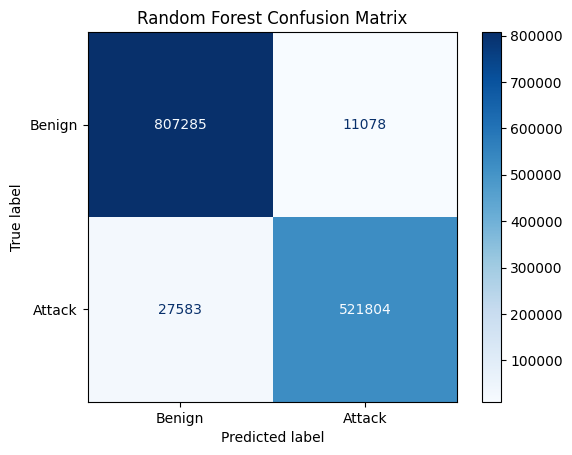

In [17]:
# ============================================
# 10. Display confusion matrix
# ============================================
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Attack"])
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [18]:
# ============================================
# 11. Per-attack detection rate
# ============================================
attack_labels = sorted([label for label in y_test_original.unique() if label != "Benign"])

rows = []
for attack in attack_labels:
    mask_attack = (y_test_original == attack)
    if mask_attack.sum() == 0:
        continue

    detection_rate = (y_pred[mask_attack] == 1).mean()
    rows.append([attack, mask_attack.sum(), detection_rate])

attack_report_df = pd.DataFrame(
    rows,
    columns=["Attack Label", "Samples", "Detection Rate"]
).sort_values(by="Detection Rate", ascending=False)

print("\nPer-attack detection rate:")
print(attack_report_df)

# show as dataframe in notebook
attack_report_df


Per-attack detection rate:
                Attack Label  Samples  Detection Rate
4       DDOS attack-LOIC-UDP      347        1.000000
10            FTP-BruteForce    38476        1.000000
9      DoS attacks-Slowloris     2167        1.000000
8   DoS attacks-SlowHTTPTest    28057        1.000000
7           DoS attacks-Hulk    92883        1.000000
6      DoS attacks-GoldenEye     8362        1.000000
13            SSH-Bruteforce    37451        1.000000
5     DDoS attacks-LOIC-HTTP   115253        0.999939
0                        Bot    57309        0.999895
3           DDOS attack-HOIC   136812        0.999868
2           Brute Force -XSS       48        0.875000
12             SQL Injection       18        0.777778
1           Brute Force -Web      124        0.645161
11             Infilteration    32080        0.142830


,Attack Label,Samples,Detection Rate
4,DDOS attack-LOIC-UDP,347,1.000000
10,FTP-BruteForce,38476,1.000000
9,DoS attacks-Slowloris,2167,1.000000
8,DoS attacks-SlowHTTPTest,28057,1.000000
7,DoS attacks-Hulk,92883,1.000000
6,DoS attacks-GoldenEye,8362,1.000000
13,SSH-Bruteforce,37451,1.000000
5,DDoS attacks-LOIC-HTTP,115253,0.999939
0,Bot,57309,0.999895
3,DDOS attack-HOIC,136812,0.999868
